# Experiment Runner

Minimal notebook for launching `run_experiment.py`, recovering the latest run, plotting training curves, and loading saved final-evaluation outputs.


## Runtime Bootstrap

On Colab, this mounts Drive, clones or updates the repo, and installs requirements. Locally it just uses the current repo.


In [1]:
import os
import subprocess
import sys
from pathlib import Path

repo_url = 'https://github.com/rbmuk/facialgen.git'
repo_dir_name = 'facialgen'

running_in_colab = False
try:
    from google.colab import drive  # type: ignore
    running_in_colab = True
except ImportError:
    drive = None

if running_in_colab:
    runtime_repo_root = Path('/content') / repo_dir_name
    if not runtime_repo_root.exists():
        print(f'Cloning repo into {runtime_repo_root} ...')
        subprocess.run(['git', 'clone', repo_url, str(runtime_repo_root)], check=True)
    else:
        print(f'Pulling latest changes in {runtime_repo_root} ...')
        subprocess.run(['git', '-C', str(runtime_repo_root), 'pull', '--ff-only'], check=True)
    os.chdir(runtime_repo_root)
    drive.mount('/content/drive')
    drive_root = Path('/content/drive/MyDrive')
    default_save_root = drive_root / 'facialgen_checkpoints'
else:
    runtime_repo_root = Path.cwd().resolve()
    default_save_root = runtime_repo_root / 'checkpoints'

print('cwd =', Path.cwd())
print('default_save_root =', default_save_root)

import importlib
for name in list(sys.modules):
    if name == 'run_experiment' or name.startswith('facialgen'):
        sys.modules.pop(name, None)
importlib.invalidate_caches()
print('Cleared cached run_experiment/facialgen imports.')

requirements_path = runtime_repo_root / 'requirements.txt'
if requirements_path.exists():
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', str(requirements_path)], check=True)
    print('Installed dependencies from', requirements_path)


Pulling latest changes in /content/facialgen ...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cwd = /content/facialgen
default_save_root = /content/drive/MyDrive/facialgen_checkpoints
Cleared cached run_experiment/facialgen imports.
Installed dependencies from /content/facialgen/requirements.txt


## Imports And Config

Set the experiment configuration here. The run folder is auto-derived from dataset, walk type, stopping mode, and model size.


In [2]:
import json
import sys
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd().resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from facialgen.train import build_run_name, resolve_run_save_dir

args = SimpleNamespace(
    dataset_name='coraml',
    data_dir='data',
    seed=2026,
    num_sign_configs=256,
    sign_seed=2026,
    epoch_seed=99,
    vertex_context_size=17,
    # walk_type: 'facial', 'facial_online', or 'random'
    walk_type='random',
    batch_size=2048,
    second_order_p=1.0,
    second_order_q=1.0,
    epochs=100,
    lr=3e-4,
    weight_decay=0.01,
    grad_clip=0.0,
    num_workers=0,
    device='auto',
    # tqdm or log
    progress_mode='log',
    n_layer=1,
    n_head=1,
    n_embd=8,
    dropout=0.,
    save_dir=str(default_save_root),
    resume_from_latest=False,
    log_every=20,
    # early_stop_mode: 'none', 'val', or 'edge_overlap'
    early_stop_mode='val',
    early_stop_patience=20,
    early_stop_min_delta=0.0,
    val_fraction=0.15,
    train_fraction=None,
    test_fraction=0.05,
    split_seed=123,
    eval_generated_walks=100_000,
    eval_generation_batch_size=2_048,
    eval_every=5,
    eval_max_length=None,
    # score_symmetrization: 'max', 'sum', or 'none'
    score_symmetrization='sum',
    debug_graph_reconstruction=False,
    target_edge_overlap=0.5,
    # edge_overlap_target: 'validation' or 'reference'
    edge_overlap_target='reference',
    use_link_prediction_split=True,
    skip_train=False,
    final_generated_walks=500_000,
    final_max_length=None,
    generation_batch_size=2_048,
    num_generated_graphs=1,
    reconstruction_seed=777,
    save_final_eval=True,
)

args.save_dir = resolve_run_save_dir(args.save_dir, args)
run_name = build_run_name(args)
print('run_name =', run_name)
print('run_dir =', args.save_dir)


run_name = coraml_random_val_L1_H1_D8
run_dir = /content/drive/MyDrive/facialgen_checkpoints/coraml_random_val_L1_H1_D8


## Run Experiment

This launches `run_experiment.py`. Use `skip_train=True` if you only want to rerun final evaluation from the latest checkpoint.


In [7]:
def build_cli_command(args):
    cmd = [sys.executable, '-u', 'run_experiment.py']
    for key, value in vars(args).items():
        flag = '--' + key.replace('_', '-')
        if value is None:
            continue
        if isinstance(value, bool):
            if key == 'save_final_eval':
                if not value:
                    cmd.append('--no-save-final-eval')
            elif value:
                cmd.append(flag)
            continue
        cmd.extend([flag, str(value)])
    return cmd

cmd = build_cli_command(args)
print('command:')
print(' '.join(map(str, cmd)))
print()
proc = subprocess.Popen(
    cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)
assert proc.stdout is not None
for line in proc.stdout:
    print(line, end='')
returncode = proc.wait()
if returncode != 0:
    raise RuntimeError(f'run_experiment.py failed with exit code {returncode}')


command:
/usr/bin/python3 -u run_experiment.py --dataset-name coraml --data-dir data --seed 2026 --num-sign-configs 256 --sign-seed 2026 --epoch-seed 99 --vertex-context-size 17 --walk-type random --batch-size 2048 --second-order-p 1.0 --second-order-q 1.0 --epochs 100 --lr 0.0003 --weight-decay 0.01 --grad-clip 0.0 --num-workers 0 --device auto --progress-mode log --n-layer 1 --n-head 1 --n-embd 8 --dropout 0.0 --save-dir /content/drive/MyDrive/facialgen_checkpoints/coraml_random_val_L1_H1_D8 --log-every 20 --early-stop-mode val --early-stop-patience 20 --early-stop-min-delta 0.0 --val-fraction 0.15 --test-fraction 0.05 --split-seed 123 --eval-generated-walks 100000 --eval-generation-batch-size 2048 --eval-every 5 --score-symmetrization sum --target-edge-overlap 0.5 --edge-overlap-target reference --use-link-prediction-split --final-generated-walks 500000 --generation-batch-size 2048 --num-generated-graphs 1 --reconstruction-seed 777

Using connected train split for VAL early stopping

## Recover Latest Run

Load the latest checkpoint directory, training history, and saved final-evaluation artifacts from the current run folder without rerunning training.


In [8]:
run_dir = Path(args.save_dir)
if not run_dir.exists():
    raise RuntimeError(f'Run directory does not exist: {run_dir}')

epoch_dirs = sorted(run_dir.glob('epoch_*'))
checkpoint_dir = epoch_dirs[-1] if epoch_dirs else (run_dir / 'final' if (run_dir / 'final').exists() else None)
print('latest_checkpoint_dir =', checkpoint_dir)

history_path = run_dir / 'history.json'
history = json.loads(history_path.read_text()) if history_path.exists() else []
history_df = pd.DataFrame(history)
display(history_df.tail())

final_lp_path = run_dir / 'final_eval_link_prediction.csv'
final_stats_path = run_dir / 'final_eval_graph_stats.csv'
final_diag_path = run_dir / 'final_eval_score_diagnostics.csv'
final_meta_path = run_dir / 'final_eval_meta.json'

lp_table = pd.read_csv(final_lp_path) if final_lp_path.exists() else pd.DataFrame()
stats_table = pd.read_csv(final_stats_path) if final_stats_path.exists() else pd.DataFrame()
diag_table = pd.read_csv(final_diag_path) if final_diag_path.exists() else pd.DataFrame()
final_meta = json.loads(final_meta_path.read_text()) if final_meta_path.exists() else {}
print('final_eval_meta =')
print(json.dumps(final_meta, indent=2))


latest_checkpoint_dir = /content/drive/MyDrive/facialgen_checkpoints/coraml_random_val_L1_H1_D8/epoch_100


,epoch,mean_nll,perplexity,eval_skipped,val_roc_auc,val_ap,val_score,edge_overlap
95,96.0,2.891341,18.017447,1.0,NaN,NaN,NaN,NaN
96,97.0,2.886189,17.924864,1.0,NaN,NaN,NaN,NaN
97,98.0,2.881154,17.834850,1.0,NaN,NaN,NaN,NaN
98,99.0,2.876319,17.748826,1.0,NaN,NaN,NaN,NaN
99,100.0,2.871509,17.663650,NaN,0.821961,0.820159,0.82106,0.471495


final_eval_meta =
{
  "dataset_name": "coraml",
  "walk_type": "random",
  "score_symmetrization": "sum",
  "edge_overlap_target": "reference",
  "final_generated_walks": 500000,
  "final_max_length": 17,
  "generation_batch_size": 2048,
  "num_generated_graphs": 1,
  "reconstruction_seed": 777,
  "checkpoint_dir": "/content/drive/MyDrive/facialgen_checkpoints/coraml_random_val_L1_H1_D8/final"
}


## Training Curves

Plot the saved training history for the current run.


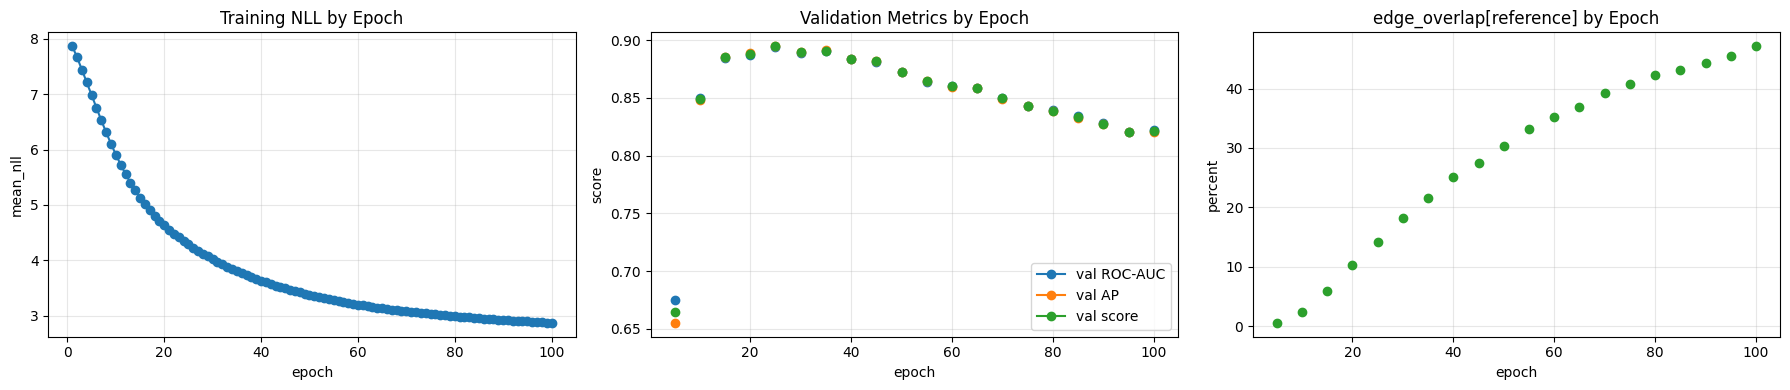

In [9]:
if history_df.empty:
    print('No history found.')
else:
    has_edge_overlap = 'edge_overlap' in history_df.columns
    ncols = 3 if has_edge_overlap else 2
    fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 4))
    axes = np.atleast_1d(axes)

    axes[0].plot(history_df['epoch'], history_df['mean_nll'], marker='o', label='train NLL')
    axes[0].set_title('Training NLL by Epoch')
    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('mean_nll')
    axes[0].grid(True, alpha=0.3)

    if 'val_roc_auc' in history_df.columns:
        axes[1].plot(history_df['epoch'], history_df['val_roc_auc'], marker='o', label='val ROC-AUC')
    if 'val_ap' in history_df.columns:
        axes[1].plot(history_df['epoch'], history_df['val_ap'], marker='o', label='val AP')
    if 'val_score' in history_df.columns:
        axes[1].plot(history_df['epoch'], history_df['val_score'], marker='o', label='val score')
    axes[1].set_title('Validation Metrics by Epoch')
    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('score')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    if has_edge_overlap:
        overlap_label = f"edge_overlap[{getattr(args, 'edge_overlap_target', 'reference')}]"
        axes[2].plot(history_df['epoch'], 100.0 * history_df['edge_overlap'], marker='o', color='tab:green')
        axes[2].set_title(f'{overlap_label} by Epoch')
        axes[2].set_xlabel('epoch')
        axes[2].set_ylabel('percent')
        axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


## Final Evaluation Data

Load and display the saved final evaluation outputs written by `run_experiment.py`.


In [10]:
print('Link prediction results:')
display(lp_table)

print('Graph statistics:')
display(stats_table)

print('Score diagnostics:')
display(diag_table)


Link prediction results:


,graph_id,val_roc_auc,val_ap,test_roc_auc,test_ap,edge_overlap[reference]
0,0,0.866476,0.86586,0.873779,0.875463,0.547175


Graph statistics:


,metric,reference,generated_mean,generated_std
0,max_degree,246.000000,229.000000,0.0
1,assortativity,-0.076592,-0.074956,0.0
2,triangle_count,5247.000000,2256.000000,0.0
3,power_law_exp,1.500883,1.484070,0.0
4,clustering_coeff,0.114298,0.059743,0.0
5,characteristic_path_len,5.271418,4.858420,0.0
6,inter_community_density,0.000526,0.000758,0.0
7,intra_community_density,0.009280,0.008155,0.0


Score diagnostics:


,graph_id,split,num_edges,min_8S_over_sumS,min_nonzero_gap
0,0,train,6385,0.0,0.000002
1,0,validation,1197,0.0,0.000002
2,0,test,399,0.0,0.000002


## Best-Validation Final Evaluation

Reload the checkpoint from the epoch with the best `val_score` and run final evaluation on that model. This is useful for older runs that already finished before the script started doing this automatically.


In [3]:
import facialgen.train as train_mod
import run_experiment as run_experiment_mod

build_training_objects = train_mod.build_training_objects
_load_history = run_experiment_mod._load_history
_load_eval_checkpoint = run_experiment_mod._load_eval_checkpoint
run_final_evaluation = run_experiment_mod.run_final_evaluation

run_dir = Path(args.save_dir)
if not run_dir.exists():
    raise RuntimeError(f'Run directory does not exist: {run_dir}')

print('progress_mode =', getattr(args, 'progress_mode', 'tqdm'))
history = _load_history(run_dir)
best_model, best_checkpoint_dir = _load_eval_checkpoint(
    run_dir,
    history,
    prefer_best_val=(str(getattr(args, 'early_stop_mode', 'none')) == 'val'),
)
print('selected_checkpoint_dir =', best_checkpoint_dir)

_, _, _, eval_info = build_training_objects(args)
lp_table_best, stats_table_best, diag_table_best = run_final_evaluation(
    args,
    model=best_model,
    eval_info=eval_info,
    checkpoint_dir=best_checkpoint_dir,
)

print('Link prediction results (best validation checkpoint):')
display(lp_table_best)

print('Graph statistics (best validation checkpoint):')
display(stats_table_best)

print('Score diagnostics (best validation checkpoint):')
display(diag_table_best)


progress_mode = log


Loading weights:   0%|          | 0/12 [00:00<?, ?it/s]

selected_checkpoint_dir = /content/drive/MyDrive/facialgen_checkpoints/coraml_random_val_L1_H1_D8/epoch_025
Using connected train split for VAL early stopping: train_edges=6385, val_edges=1197, test_edges=399
Dataset: coraml
Walk type: random
LCC nodes: 2810
Random-walk samples: 217941
Training samples @ T=17: 217941
Vocab: 2813 (vertices + BOS + EOS + PAD)
final generation max_length = 17
final graph 1/1: sampling 500000 walks
final sampling graph 1/1: sampled 51200/500000
final sampling graph 1/1: sampled 100352/500000
final sampling graph 1/1: sampled 151552/500000
final sampling graph 1/1: sampled 200704/500000
final sampling graph 1/1: sampled 251904/500000
final sampling graph 1/1: sampled 301056/500000
final sampling graph 1/1: sampled 350208/500000
final sampling graph 1/1: sampled 401408/500000
final sampling graph 1/1: sampled 450560/500000
final sampling graph 1/1: sampled 500000/500000
final graph 1/1: graph reconstruction
[graph reconstruction 1/1] aggregating scores (mode

,graph_id,val_roc_auc,val_ap,test_roc_auc,test_ap,edge_overlap[reference]
0,0,0.929664,0.932014,0.941505,0.945723,0.173662


Graph statistics (best validation checkpoint):


,metric,reference,generated_mean,generated_std
0,max_degree,246.000000,170.000000,0.0
1,assortativity,-0.076592,-0.077975,0.0
2,triangle_count,5247.000000,690.000000,0.0
3,power_law_exp,1.500883,1.465420,0.0
4,clustering_coeff,0.114298,0.023633,0.0
5,characteristic_path_len,5.271418,4.473245,0.0
6,inter_community_density,0.000526,0.001195,0.0
7,intra_community_density,0.009280,0.006035,0.0


Score diagnostics (best validation checkpoint):


,graph_id,split,num_edges,min_8S_over_sumS,min_nonzero_gap
0,0,train,6385,0.0,0.000002
1,0,validation,1197,0.0,0.000002
2,0,test,399,0.0,0.000002
